In [1]:
import tensorflow as tf
import cv2
import imghdr
import os
from google.colab import drive
from pathlib import Path


/tmp/ipykernel_1162/1998246275.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu,True)

In [3]:
drive.mount('/content/drive')
image_exts = ['jpeg','jpg','png','bmp']


Mounted at /content/drive


In [4]:
data_dir = "/content/drive/MyDrive/data"
os.listdir(data_dir)

['sad', 'happy']

In [5]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir,image_class)):
        image_path = os.path.join(data_dir,image_class,image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in the ext list{}'.format(image_path))
                os.remove(image_path)
        except Exception as ex:
            print('Issye with the image {}'.format(image_path))

In [63]:
import numpy as np 
from matplotlib import pyplot as plt 

In [64]:
data = tf.keras.utils.image_dataset_from_directory('/content/drive/MyDrive/data')

Found 973 files belonging to 2 classes.


In [65]:
data_iterator = data.as_numpy_iterator()

In [66]:
batch = data_iterator.next()
batch[0].shape

(32, 256, 256, 3)

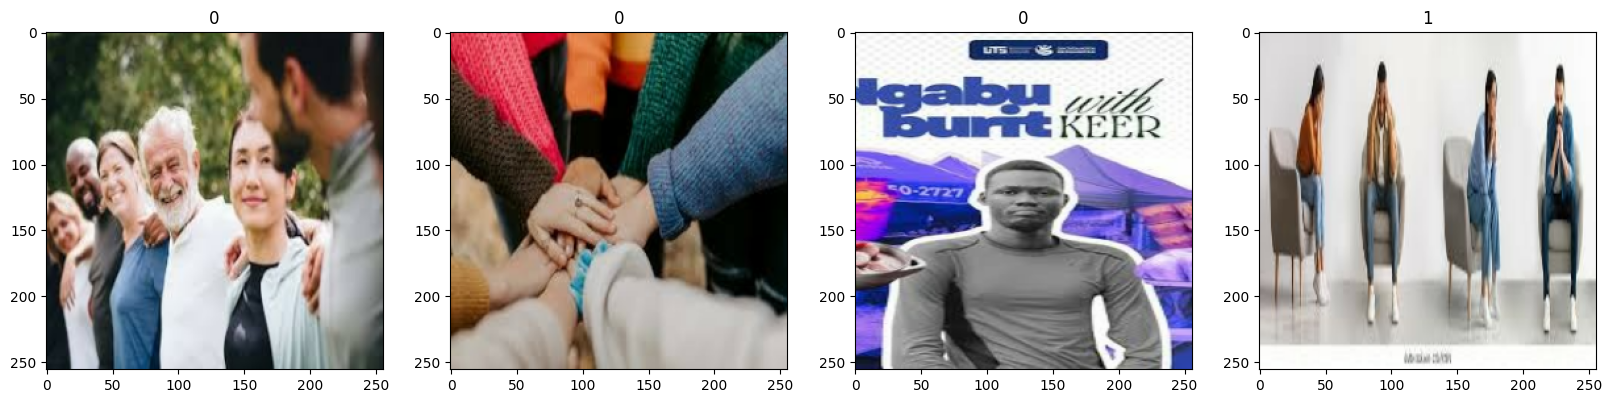

In [67]:
fig,ax = plt.subplots(ncols= 4 , figsize = (20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [68]:
#Class 1 - sad people, Happy People - 1 
data = data.map(lambda x,y: (x/255,y))

In [69]:
scaled_interator = data.as_numpy_iterator()

In [70]:
batch = scaled_interator.next()

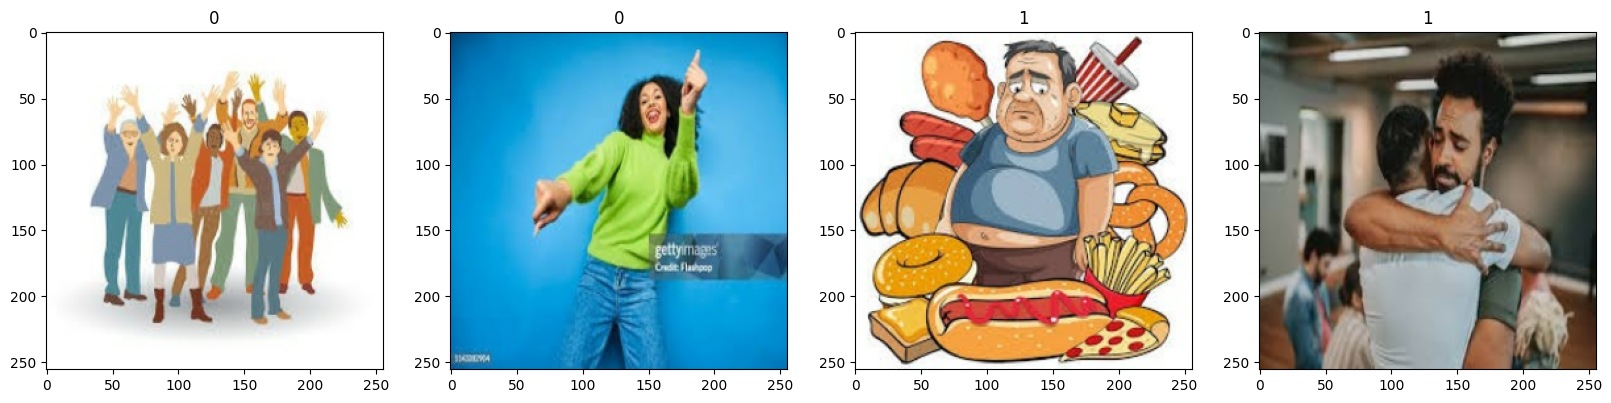

In [71]:
fig,ax = plt.subplots(ncols= 4 , figsize = (20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [72]:
len(data)

31

In [73]:
train_size = int(len(data)*0.7)
val_size = int(len(data)*0.2)+1
test_size = int(len(data)*0.1)

In [74]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [75]:
#Building the deep learning network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout

In [76]:
model = Sequential()

In [77]:
model.add(Conv2D(16,(3,3),1,activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())


model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
model.compile('adam',loss = tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [79]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
hist = model.fit(train,epochs=15,validation_data=val)

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step - accuracy: 0.4997 - loss: 1.0797 - val_accuracy: 0.5580 - val_loss: 0.6899
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.6100 - loss: 0.6834 - val_accuracy: 0.6205 - val_loss: 0.6768
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - accuracy: 0.6604 - loss: 0.6466 - val_accuracy: 0.6295 - val_loss: 0.6465
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.7392 - loss: 0.5676 - val_accuracy: 0.6429 - val_loss: 0.6278
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.7521 - loss: 0.5395 - val_accuracy: 0.7366 - val_loss: 0.4982
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.7715 - loss: 0.4872 - val_accuracy: 0.7054 - val_loss: 0.5748
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.8258 - loss: 0.3838 - val_accuracy: 0.7991 - val_loss: 0.4550
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.9078 - loss: 0.2699 - val_accuracy: 0.

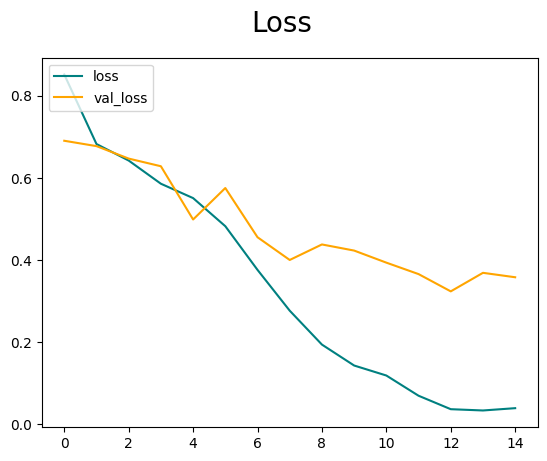

In [81]:
fig = plt.figure()
plt.plot(hist.history['loss'],color = 'teal',label = 'loss')
plt.plot(hist.history['val_loss'],color = 'orange',label = 'val_loss')
fig.suptitle('Loss',fontsize = 20)
plt.legend(loc ='upper left')
plt.show()

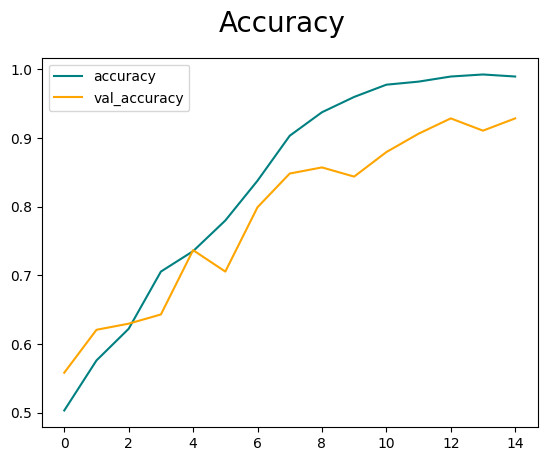

In [82]:
fig = plt.figure()
plt.plot(hist.history['accuracy'],color = 'teal',label = 'accuracy')
plt.plot(hist.history['val_accuracy'],color = 'orange',label = 'val_accuracy')
fig.suptitle('Accuracy',fontsize = 20)
plt.legend(loc ='upper left')
plt.show()

In [83]:
#Evaluation
from tensorflow.keras.metrics import Precision,Recall,BinaryAccuracy
pre= Precision()
re =Recall()
acc = BinaryAccuracy()

In [84]:
for batch in test.as_numpy_iterator():
    X,y = batch
    yhat = model.predict(X)
    pre.update_state(y,yhat)
    re.update_state(y,yhat)
    acc.update_state(y,yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


In [85]:
print(f'Precision:{ pre.result().numpy()}, Recall:{re.result().numpy()},Accuracy:{acc.result().numpy()}')

Precision:0.9090909361839294, Recall:0.9090909361839294,Accuracy:0.9220778942108154


In [86]:
sad = '/content/drive/MyDrive/sad.jpg'
happy = '/content/drive/MyDrive/happy.jpg'

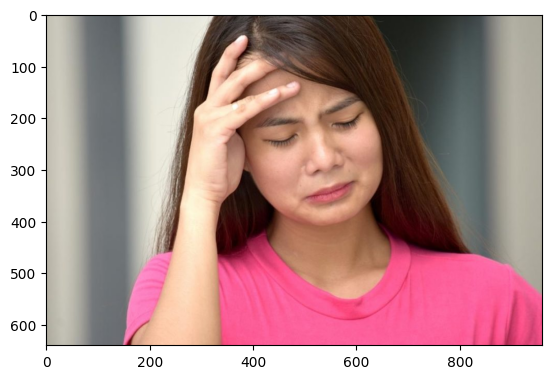

In [95]:
img = cv2.imread(sad)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.show()

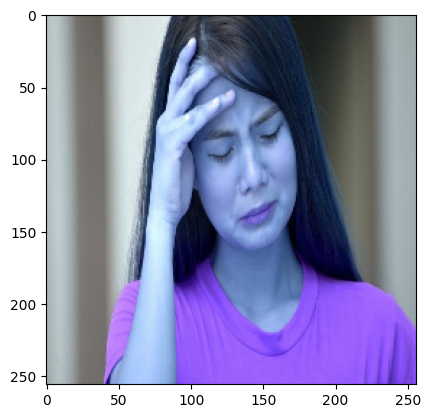

In [96]:
resize  = tf.image.resize(img,(256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [97]:
yhat = model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [98]:
yhat

array([[0.8865865]], dtype=float32)